## Data-analyse dag 3

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

from lmfit import models

### Data from measurements

In [106]:
#First measurements

dist_noz = [5.6,5.6,5.6,6.6,6.6,6.6,7.6,7.6,7.6,8.6,8.6,8.6,9.6,9.6,9.6,]
med_vol = [185.309967041,233.603973389,248.303009033,168.871261597,182.77796936,227.372680664,213.433013916,205.360137939,159.382064819,179.57963562,228.407089233,220.441680908,178.961242676,225.229476929,207.024429321]

#Second measurements

dist_noz2 = [14.6, 14.6, 14.6, 19.6, 19.6, 19.6, 24.6, 24.6, 24.6, 29.6, 29.6, 29.6]
med_vol2 = [218.053482056, 203.824478149, 288.871520996, 199.194839478, 287.242156982, 202.166030884, 295.660003662, 255.159286499, 352.483734131, 195.687957764, 378.388549805, 260.056274414]

#Total

dist_noz_tot = [5.6,5.6,5.6,6.6,6.6,6.6,7.6,7.6,7.6,8.6,8.6,8.6,9.6,9.6,9.6,14.6, 14.6, 14.6, 19.6, 19.6, 19.6, 24.6, 24.6, 24.6, 29.6, 29.6, 29.6]
med_vol_tot = [185.309967041,233.603973389,248.303009033,168.871261597,182.77796936,227.372680664,213.433013916,205.360137939,159.382064819,179.57963562,228.407089233,220.441680908,178.961242676,225.229476929,207.024429321, 218.053482056, 203.824478149, 288.871520996, 199.194839478, 287.242156982, 202.166030884, 295.660003662, 255.159286499, 352.483734131, 195.687957764, 378.388549805, 260.056274414]

print(len(dist_noz_tot),len(med_vol_tot))

27 27


## Faults

In [107]:
#Faults first measurements

err_dist_noz = [0.2]*15
err_med_vol = [18.6572856903,33.7856254578,54.365020752, 8.93819904327,18.123085022,36.7641181946,26.54155159,21.3621444702,8.58355808258,13.638338089,25.2518672943,23.2559738159,16.7435188293,28.5867786407,25.8330287933]

#Faults second measurements

err_dist_noz2 = [0.2]*12
err_med_vol2 = [29.673204422, 29.4546356201, 30.9118824005, 25.4285373688, 36.485786438, 22.9062271118, 35.8325424194, 37.772731781, 32.9526481628,  38.6901092529, 48.8066749573, 40.9168815613]

#Faults total

err_dist_noz_tot = [0.2]*27
err_med_vol_tot = [18.6572856903,33.7856254578,54.365020752, 8.93819904327,18.123085022,36.7641181946,26.54155159,21.3621444702,8.58355808258,13.638338089,25.2518672943,23.2559738159,16.7435188293,28.5867786407,25.8330287933,29.673204422, 29.4546356201, 30.9118824005, 25.4285373688, 36.485786438, 22.9062271118, 35.8325424194, 37.772731781, 32.9526481628,  38.6901092529, 48.8066749573, 40.9168815613]

print(len(err_dist_noz_tot),len(err_med_vol_tot))

27 27


## Plots of first measurement

Text(0, 0.5, 'Median droplet volume')

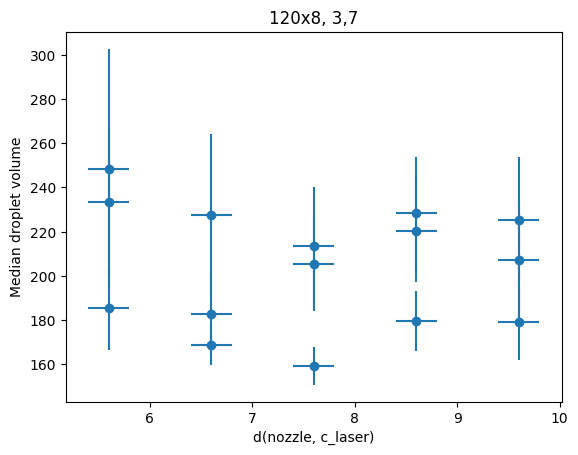

In [108]:
plt.figure()

plt.errorbar(dist_noz, med_vol, xerr=err_dist_noz, yerr=err_med_vol, fmt='o')

plt.title(r"120x8, 3,7")
plt.xlabel(r"d(nozzle, c_laser)")
plt.ylabel(r"Median droplet volume")

## Fitfunction first measurement

In [109]:
def fit_function1(x_fit, p1, p2, ):
    med_vol = p1 * x_fit + p2  
    return med_vol

In [110]:
fit_model1 = models.Model(fit_function1)

In [111]:
err_med_vol_array = np.array(err_med_vol)
err_med_vol_inv = 1 / err_med_vol_array

In [112]:
fit_result = fit_model1.fit(med_vol, x_fit=np.array(dist_noz), weights=err_med_vol_inv, p1=1.5, p2=1.5)

Text(0, 0.5, 'Median volume of droplets')

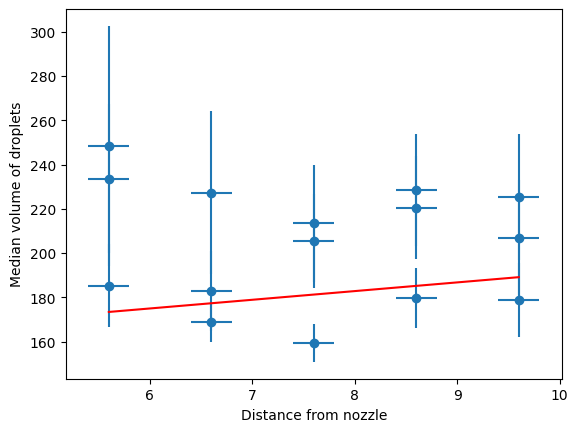

In [113]:
plt.figure()

plt.errorbar(dist_noz, med_vol, xerr=err_dist_noz, yerr=err_med_vol, fmt='o')
plt.plot(dist_noz, fit_result.best_fit, 'r-')

plt.xlabel(r'Distance from nozzle')
plt.ylabel(r'Median volume of droplets')

In [114]:
print(fit_result.fit_report())

[[Model]]
    Model(fit_function1)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 15
    # variables        = 2
    chi-square         = 25.3984424
    reduced chi-square = 1.95372634
    Akaike info crit   = 11.8995647
    Bayesian info crit = 13.3156651
    R-squared          = -0.88653699
[[Variables]]
    p1:  3.92947807 +/- 5.42363803 (138.02%) (init = 1.5)
    p2:  151.379717 +/- 41.3510305 (27.32%) (init = 1.5)
[[Correlations]] (unreported correlations are < 0.100)
    C(p1, p2) = -0.9891


## Plot second measurement

Text(0, 0.5, 'Median droplet volume')

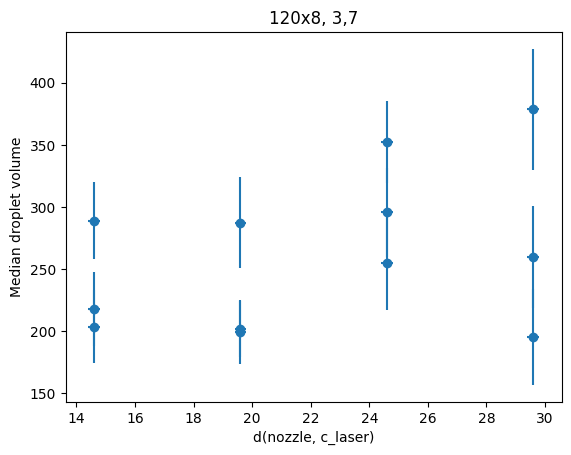

In [115]:
plt.figure()

plt.errorbar(dist_noz2, med_vol2, xerr=err_dist_noz2, yerr=err_med_vol2, fmt='o')

plt.title(r"120x8, 3,7")
plt.xlabel(r"d(nozzle, c_laser)")
plt.ylabel(r"Median droplet volume")

## Fit second measure

In [116]:
def fit_function2(x_fit2, a1, a2, ):
    med_vol2 = a1 * x_fit2 + a2  
    return med_vol2

In [117]:
fit_model2 = models.Model(fit_function2)

In [118]:
err_med_vol2_array = np.array(err_med_vol2)
err_med_vol2_inv = 1 / err_med_vol2_array

In [119]:
fit_result2 = fit_model2.fit(med_vol2, x_fit2=np.array(dist_noz2), weights=err_med_vol2_inv, a1=1.5, a2=1.5)

Text(0, 0.5, 'Median volume of droplets')

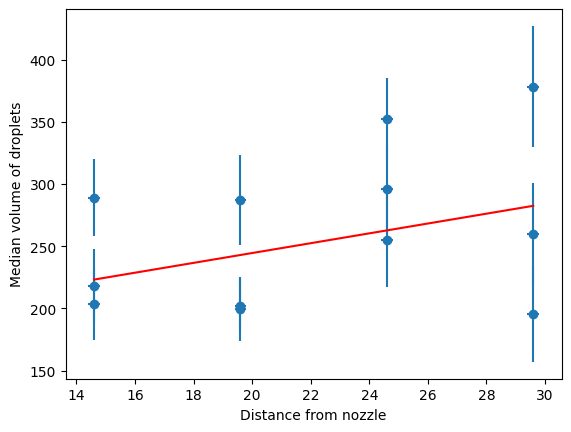

In [120]:
plt.figure()

plt.errorbar(dist_noz2, med_vol2, xerr=err_dist_noz2, yerr=err_med_vol2, fmt='o')
plt.plot(dist_noz2, fit_result2.best_fit, 'r-')

plt.xlabel(r'Distance from nozzle')
plt.ylabel(r'Median volume of droplets')

In [121]:
print(fit_result2.fit_report())

[[Model]]
    Model(fit_function2)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 12
    # variables        = 2
    chi-square         = 30.0825409
    reduced chi-square = 3.00825409
    Akaike info crit   = 15.0284598
    Bayesian info crit = 15.9982731
    R-squared          = 0.11627683
[[Variables]]
    a1:  3.95513148 +/- 3.17117889 (80.18%) (init = 1.5)
    a2:  165.461106 +/- 67.4251551 (40.75%) (init = 1.5)
[[Correlations]] (unreported correlations are < 0.100)
    C(a1, a2) = -0.9711


## Now we combine the results

Text(0, 0.5, 'Median droplet volume')

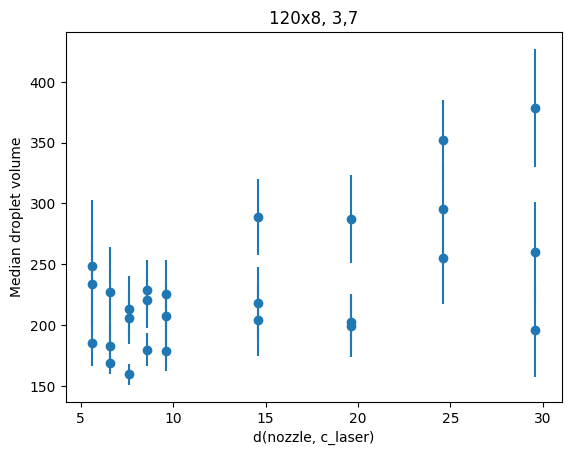

In [122]:
plt.figure()

plt.errorbar(dist_noz_tot, med_vol_tot, xerr=err_dist_noz_tot, yerr=err_med_vol_tot, fmt='o')

plt.title(r"120x8, 3,7")
plt.xlabel(r"d(nozzle, c_laser)")
plt.ylabel(r"Median droplet volume")

In [123]:
def fit_function3(x_fit_tot, b1, b2, ):
    med_vol_tot = b1 * x_fit_tot + b2  
    return med_vol_tot

In [124]:
fit_model3 = models.Model(fit_function3)

In [125]:
err_med_vol_tot_array = np.array(err_med_vol_tot)
err_med_vol_tot_inv = 1 / err_med_vol_tot_array

In [126]:
fit_result3 = fit_model3.fit(med_vol_tot, x_fit_tot=np.array(dist_noz_tot), weights=err_med_vol_tot_inv, b1=1.5, b2=1.5)

Text(0, 0.5, 'Median volume of droplets')

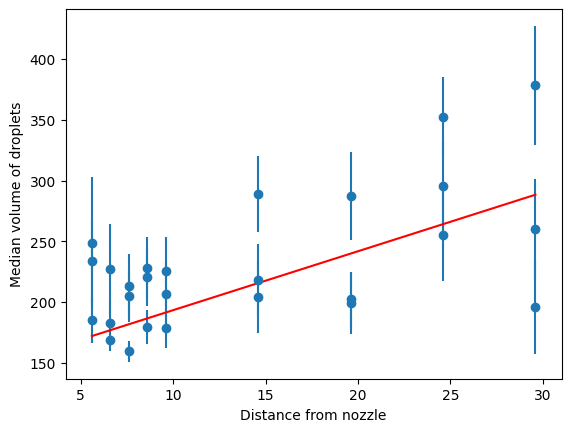

In [127]:
plt.figure()

plt.errorbar(dist_noz_tot, med_vol_tot, xerr=err_dist_noz_tot, yerr=err_med_vol_tot, fmt='o')
plt.plot(dist_noz_tot, fit_result3.best_fit, 'r-')

plt.xlabel(r'Distance from nozzle')
plt.ylabel(r'Median volume of droplets')

In [128]:
print(fit_result3.fit_report())

[[Model]]
    Model(fit_function3)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 27
    # variables        = 2
    chi-square         = 55.8384726
    reduced chi-square = 2.23353890
    Akaike info crit   = 23.6189085
    Bayesian info crit = 26.2105822
    R-squared          = 0.23409632
[[Variables]]
    b1:  4.84446518 +/- 1.05642045 (21.81%) (init = 1.5)
    b2:  144.953293 +/- 12.0157563 (8.29%) (init = 1.5)
[[Correlations]] (unreported correlations are < 0.100)
    C(b1, b2) = -0.8714


## We wanted to test the effects of adding a filter to the setup

## Data of additional measurements

In [129]:
#Orange needle without filter

dist_noz3 = [7.3]*9

med_vol3 = [420.497924805, 362.431549072, 400.205169678, 416.90737915, 418.969116211, 404.871795654, 415.661529541, 417.379241943, 420.110687256]

#Orange needle with filter

dist_noz4 = [7.3]*9

med_vol4 = [440.603820801,438.253875732, 426.914855957, 423.341308594, 389.029510498, 491.683166504, 359.91217041, 418.207244873, 397.287811279]

### Faults

In [130]:
err_dist_noz3 = [0.2]*9

err_med_vol3 = [133.158355713, 101.457046509, 147.257965088, 124.548278809, 143.623336792, 142.294464111, 143.47479248, 140.694839478, 136.221328735]

err_dist_noz4 = [0.2]*9

err_med_vol4 = [126.487785339, 115.054450989, 112.552841187, 133.063278198, 119.972091675, 123.562019348, 132.21875, 147.387588501, 117.560272217]

### Plots met en zonder filter

Text(0, 0.5, 'Median droplet volume')

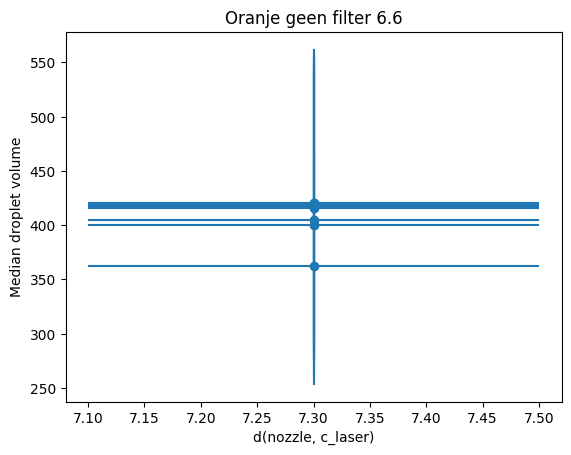

In [131]:
plt.figure()

plt.errorbar(dist_noz3, med_vol3, xerr=err_dist_noz3, yerr=err_med_vol3, fmt='o')

plt.title(r"Oranje geen filter 6.6")
plt.xlabel(r"d(nozzle, c_laser)")
plt.ylabel(r"Median droplet volume")

Text(0, 0.5, 'Median droplet volume')

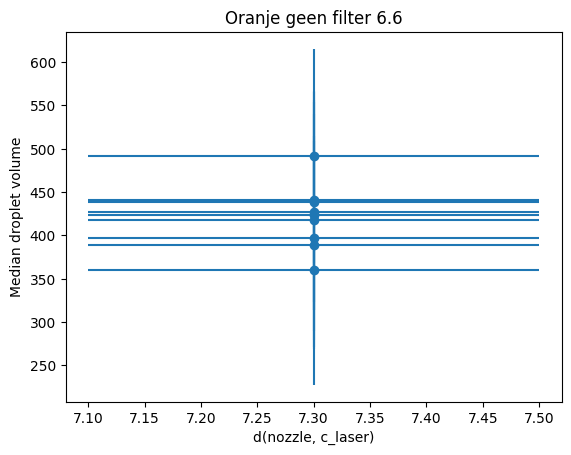

In [132]:
plt.figure()

plt.errorbar(dist_noz4, med_vol4, xerr=err_dist_noz4, yerr=err_med_vol4, fmt='o')

plt.title(r"Oranje geen filter 6.6")
plt.xlabel(r"d(nozzle, c_laser)")
plt.ylabel(r"Median droplet volume")

### fitfuncties

In [133]:
def fit_function4(x_fit3, c1):
    med_vol3 = 0*x_fit3 + c1  
    return med_vol3

In [134]:
fit_model4 = models.Model(fit_function4)


In [135]:
def fit_function5(x_fit4, d1):
    med_vol4 = 0* x_fit4 + d1  
    return med_vol4

In [136]:
fit_model5 = models.Model(fit_function5)

In [137]:
err_med_vol3_array = np.array(err_med_vol3)
err_med_vol3_inv = 1 / err_med_vol3_array

err_med_vol4_array = np.array(err_med_vol4)
err_med_vol4_inv = 1 / err_med_vol4_array

In [138]:
fit_result4 = fit_model4.fit(med_vol3, x_fit3=np.array(dist_noz3), weights=err_med_vol3_inv, c1=1.5)

fit_result5 = fit_model5.fit(med_vol4, x_fit4=np.array(dist_noz4), weights=err_med_vol4_inv, d1=1.5)

Text(0, 0.5, 'Median volume of droplets')

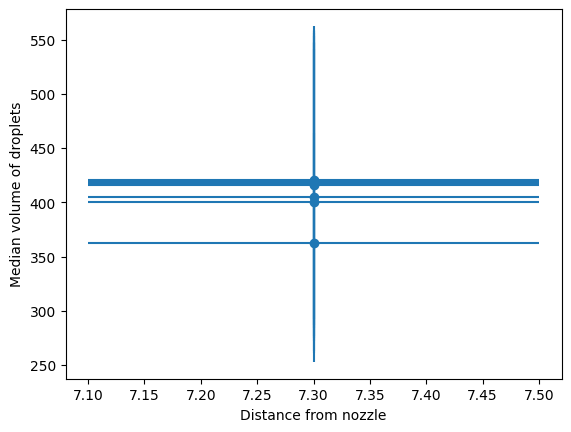

In [139]:
plt.figure()

plt.errorbar(dist_noz3, med_vol3, xerr=err_dist_noz3, yerr=err_med_vol3, fmt='o')
plt.plot(dist_noz3, fit_result4.best_fit, 'r-')

plt.xlabel(r'Distance from nozzle')
plt.ylabel(r'Median volume of droplets')

In [140]:
print(fit_result4.fit_report())

[[Model]]
    Model(fit_function4)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 9
    # variables        = 1
    chi-square         = 0.23480101
    reduced chi-square = 0.02935013
    Akaike info crit   = -30.8161731
    Bayesian info crit = -30.6189485
    R-squared          = -0.04475807
[[Variables]]
    c1:  404.832184 +/- 7.54935264 (1.86%) (init = 1.5)


Text(0, 0.5, 'Median volume of droplets')

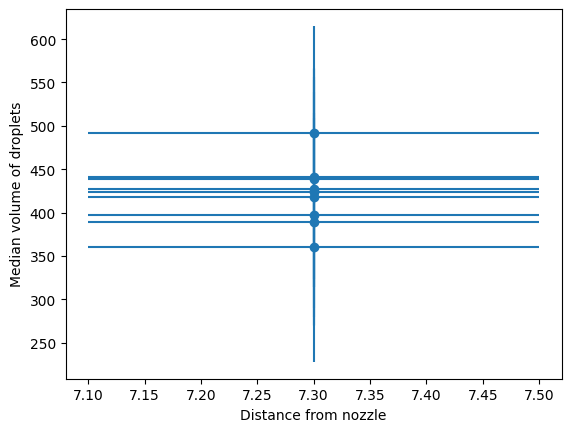

In [141]:
plt.figure()

plt.errorbar(dist_noz4, med_vol4, xerr=err_dist_noz4, yerr=err_med_vol4, fmt='o')
plt.plot(dist_noz4, fit_result5.best_fit, 'r-')

plt.xlabel(r'Distance from nozzle')
plt.ylabel(r'Median volume of droplets')

In [142]:
print(fit_result5.fit_report())

[[Model]]
    Model(fit_function5)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 9
    # variables        = 1
    chi-square         = 0.70226984
    reduced chi-square = 0.08778373
    Akaike info crit   = -20.9559593
    Bayesian info crit = -20.7587347
    R-squared          = -4.6690e-04
[[Variables]]
    d1:  421.338350 +/- 12.2599615 (2.91%) (init = 1.5)
